<a href="https://colab.research.google.com/github/mmovahed/Applied-Scientific-Computing-with-Python/blob/master/FFT_IE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Steps to Solve Using FFT

1. **Discretization**:
   - Define a grid of points $( x_n )$ where $( n = 0, 1, 2, \ldots, N-1 )$.
   - Choose an appropriate spacing $( \Delta x )$ for the grid. The grid points would be $( x_n = n \Delta x )$.

2. **Discretize the Functions**:
   - Evaluate $( g(x) )$ at each grid point: $( g_n = g(x_n) )$.
   - Approximate the unknown function $( f(x) )$ at these points as $( f_n = f(x_n) )$.

3. **Apply FFT to Convolution**:
   - The convolution integral can be approximated by a discrete convolution, which in turn can be computed efficiently using FFT.
   - Compute the Fourier transforms of $( K(x) )$ and $( f(x) )$ using FFT:
   
   \begin{equation}
   \hat{K}_k = \text{FFT}\{K_n\}, \quad \hat{f}_k = \text{FFT}\{f_n\}
   \end{equation}

   - Multiply these in the Fourier domain:
   \begin{equation}
     \hat{F}_k = \hat{K}_k \cdot \hat{f}_k
   \end{equation}

   - Perform the inverse FFT to get the result back in the spatial domain:

\begin{equation}
     F_n = \text{IFFT}\{\hat{F}_k\}
   \end{equation}

4. **Solve the Discrete Equation**:
   - After applying FFT, the equation in the frequency domain looks like:
   
    \begin{equation}
   \hat{f}_k = \frac{1}{2} \hat{F}_k + \hat{g}_k
   \end{equation}

     where $( \hat{g}_k = \text{FFT}\{g_n\} )$.

   - Solve for $( \hat{f}_k )$:

\begin{equation}
     \hat{f}_k = \frac{\hat{g}_k}{1 - \frac{1}{2} \hat{K}_k}
   \end{equation}

   - Compute the inverse FFT to obtain the solution $( f_n )$:
\begin{equation}
     f_n = \text{IFFT}\{\hat{f}_k\}
   \end{equation}

5. **Interpretation**:
   - The values $( f_n )$ represent the numerical approximation of the solution $( f(x) )$ at the grid points $( x_n )$.

### Example

$u(x)=e^{-x^2}+\frac{1}{2} \int_{-\infty}^{\infty}e^{-|x-t|}u(t)dt$

With exact solution:

$u(x)=e^{-x^2}$

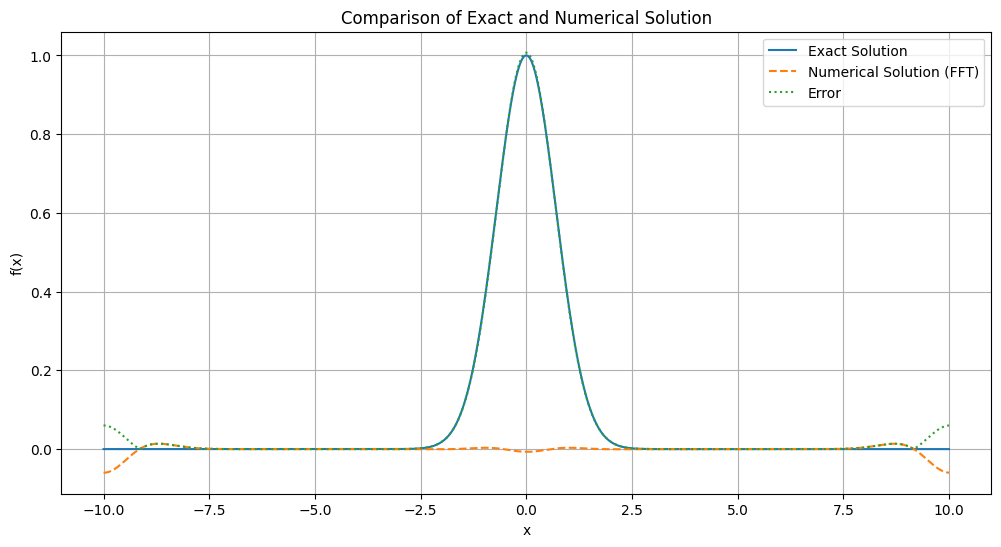

Mean absolute error: 0.09275921167524051


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
N = 1024  # Number of grid points
L = 10    # Length of the domain
x = np.linspace(-L, L, N)
dx = x[1] - x[0]

# Define the kernel and the known function
K = np.exp(-np.abs(x))
g = np.exp(-x**2)

# Compute the FFT of the kernel and the known function
K_hat = np.fft.fft(K)
g_hat = np.fft.fft(g)

# Solve the equation in Fourier space
f_hat = g_hat / (1 - 0.5 * K_hat)

# Compute the inverse FFT to get the solution in real space
f_numerical = np.fft.ifft(f_hat).real

# Exact solution
f_exact = np.exp(-x**2)

# Compute error
error = np.abs(f_exact - f_numerical)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, f_exact, label='Exact Solution')
plt.plot(x, f_numerical, label='Numerical Solution (FFT)', linestyle='--')
plt.plot(x, error, label='Error', linestyle=':')
plt.legend()
plt.title('Comparison of Exact and Numerical Solution')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()

# Print the MAE
print(f"Mean absolute error: {np.mean(error)}")